In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import pickle

with open(f"activations_save/activations_vit_cifar100.pkl", "rb") as f:
    activations = pickle.load(f)

In [5]:
activations.keys()

dict_keys(['layer_0.input_layernorm', 'layer_0.self_attn_k_proj', 'layer_0.self_attn_v_proj', 'layer_0.self_attn_q_proj', 'layer_0.self_attn_o_proj', 'layer_0.post_attention_layernorm', 'layer_0.mlp_gate_proj', 'layer_0.mlp_up_proj', 'layer_0.mlp_down_proj', 'layer_1.input_layernorm', 'layer_1.self_attn_k_proj', 'layer_1.self_attn_v_proj', 'layer_1.self_attn_q_proj', 'layer_1.self_attn_o_proj', 'layer_1.post_attention_layernorm', 'layer_1.mlp_gate_proj', 'layer_1.mlp_up_proj', 'layer_1.mlp_down_proj', 'layer_2.input_layernorm', 'layer_2.self_attn_k_proj', 'layer_2.self_attn_v_proj', 'layer_2.self_attn_q_proj', 'layer_2.self_attn_o_proj', 'layer_2.post_attention_layernorm', 'layer_2.mlp_gate_proj', 'layer_2.mlp_up_proj', 'layer_2.mlp_down_proj', 'layer_3.input_layernorm', 'layer_3.self_attn_k_proj', 'layer_3.self_attn_v_proj', 'layer_3.self_attn_q_proj', 'layer_3.self_attn_o_proj', 'layer_3.post_attention_layernorm', 'layer_3.mlp_gate_proj', 'layer_3.mlp_up_proj', 'layer_3.mlp_down_proj

In [6]:
activations['layer_0.self_attn_o_proj']['output'][0].shape

torch.Size([16, 197, 768])

In [9]:
def analyze_output_singular_values(layer_name):
    # 一共有12层，把每一层的输出奇异值分布绘制到一张图上，折线图形式
    layer_indices = []
    layer_avg_svs = []
    
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])  # e.g., "layers.0"
        # outputs = activations[layer]["output"]  # list of tensors

        # total_singular_values = 0
        
        # for output in outputs:
        #     tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        #     if not isinstance(tensor, torch.Tensor):
        #         continue
        #     singular_values = torch.linalg.svdvals(tensor)
        #     total_singular_values += singular_values.sum().item()
            
        # avg_singular_value = total_singular_values / len(outputs)
        
        # layer_indices.append(layer_id)
        # layer_avg_svs.append(avg_singular_value)
        
        output = activations[layer]["output"][0]
        tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        # U, S, Vh = torch.linalg.svd(tensor, full_matrices=False)
        singular_values = torch.linalg.svdvals(tensor)
        
        layer_indices.append(layer_id)
        layer_avg_svs.append(singular_values)
        
    return layer_indices, layer_avg_svs


In [10]:
def plot_singular_value_distribution(layer_ids, layer_svs, layer_name):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv.cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-3
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [11]:
def plot_singular_value_topX_distribution(layer_ids, layer_svs, layer_name, X=10):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv[:X].cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name} top {X}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-1
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [12]:
layer_name = "attn_o_proj"
layer_ids, layer_svs = analyze_output_singular_values(layer_name)

/tmp/ipykernel_2546523/3106386022.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


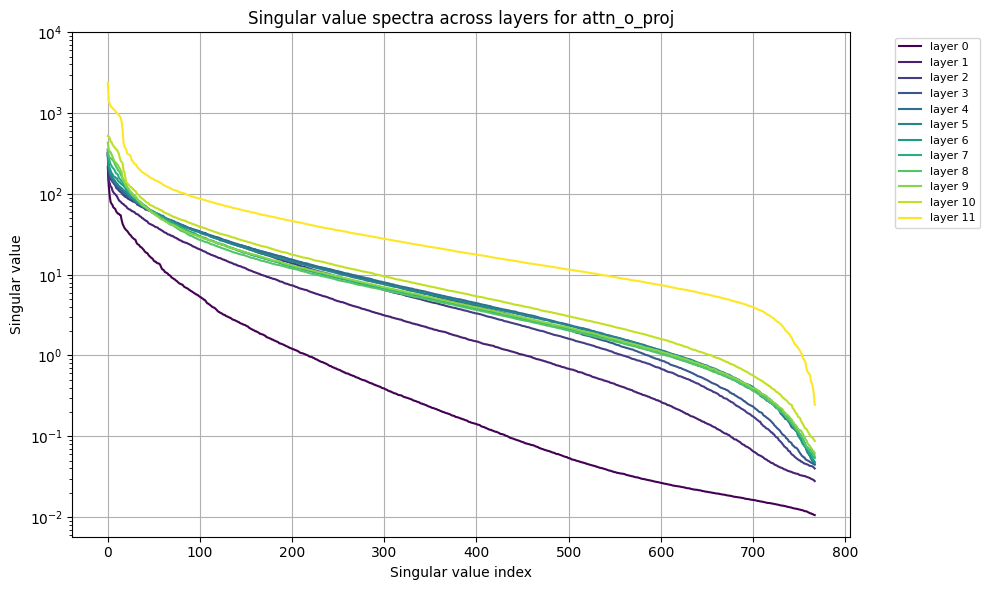

In [13]:
plot_singular_value_distribution(layer_ids, layer_svs, 'attn_o_proj')

/tmp/ipykernel_2546523/3210539342.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


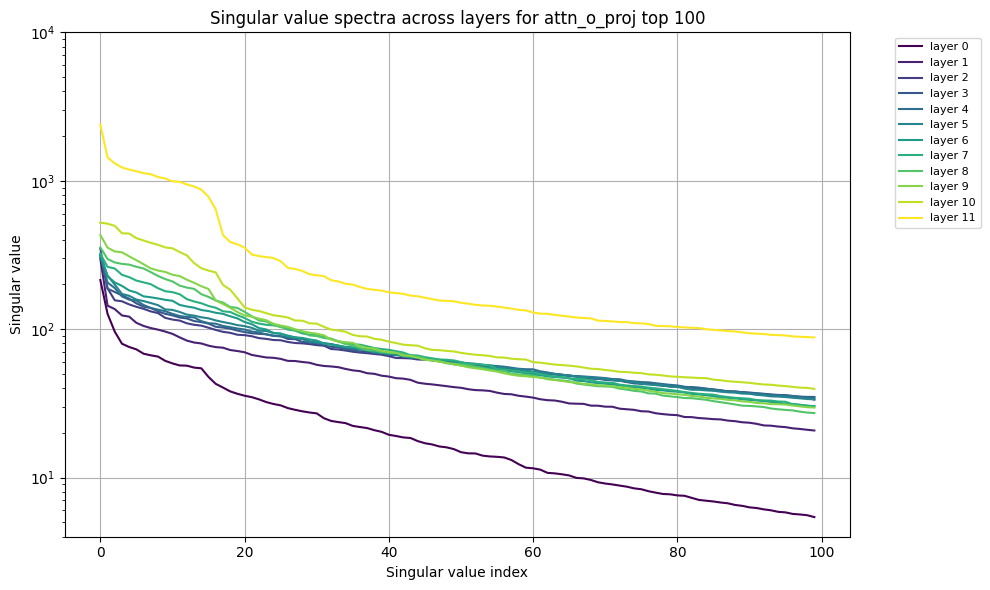

In [14]:
plot_singular_value_topX_distribution(layer_ids, layer_svs, 'attn_o_proj', X=100)

In [15]:
from meft.linalg.qb import randomized_qb

/home/chenxy/miniconda3/envs/loract/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
tensor = activations['layer_11.self_attn_o_proj']["output"][0].reshape(-1, activations['layer_11.self_attn_o_proj']["output"][0].shape[-1]).to(torch.float32).to(device)
print(tensor.shape)

Q, B = randomized_qb(tensor, rank=128)

torch.Size([3152, 768])


In [18]:
Q.shape, B.shape

(torch.Size([3152, 128]), torch.Size([128, 768]))

In [19]:
R = tensor - Q @ B
R.shape
R

tensor([[-0.2274, -0.4515, -0.2949,  ...,  0.6836,  0.5688,  1.2739],
        [-0.5159, -0.0575, -0.1027,  ..., -0.8459, -0.3921,  0.4115],
        [-0.0040, -1.2940,  0.1275,  ...,  1.4768, -0.1574, -0.6004],
        ...,
        [-0.2781,  0.4309, -1.0714,  ..., -1.2604,  0.3648, -0.7691],
        [-0.8174,  0.4238, -0.7415,  ..., -1.7809,  0.3200, -0.6970],
        [-0.0263,  0.2114,  0.5747,  ..., -0.4342, -0.4237,  0.3822]],
       device='cuda:0')

In [20]:
R.max(), R.min(), R.mean(), R.std()

(tensor(4.2491, device='cuda:0'),
 tensor(-3.5709, device='cuda:0'),
 tensor(-2.0495e-05, device='cuda:0'),
 tensor(0.4997, device='cuda:0'))

In [21]:
torch.sum(R.abs() > 1e-2)

tensor(2375991, device='cuda:0')

R stats: min = -3.5708604 max = 4.249115 mean = -2.0494823e-05


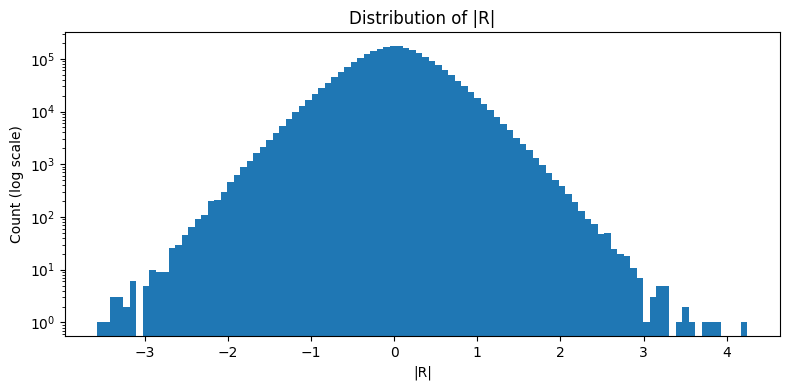

In [22]:
import numpy as np

R_flat = R.detach().reshape(-1).cpu().numpy()  # 取绝对值再拉平

print("R stats:",
      "min =", R_flat.min(),
      "max =", R_flat.max(),
      "mean =", R_flat.mean())

plt.figure(figsize=(8, 4))
plt.hist(R_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|R|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |R|")
plt.tight_layout()
plt.show()

In [24]:
import bitsandbytes as bnb

quant_state = bnb.functional.quantize_4bit(
    R,
    quant_type="nf4",  # 指定 NF4 格式（适配正态分布的 R）
    blocksize=128,      # 分块量化，平衡精度/速度
    # blocksize=R.shape[-1],  # 不分块
    compress_statistics=True
)

R_nf4_dequant = bnb.functional.dequantize_4bit(*quant_state)

mse = torch.mean((R - R_nf4_dequant)**2)
print(f"NF4 量化 MSE: {mse.item()}")

mae = torch.mean(torch.abs(R - R_nf4_dequant))
print(f"NF4 量化 MAE: {mae.item()}")

NF4 量化 MSE: 0.0023140590637922287
NF4 量化 MAE: 0.037356823682785034
